# Welcome to the Tactik Text Clustering Workshop! 🚀

In this workshop, you'll learn how to automatically organize and analyze large collections of text documents.
We'll walk through each step of the pipeline:

1. **Text Preprocessing** - Cleaning and preparing raw text
2. **Embeddings** - Converting text into numbers computers can understand
3. **Clustering Tuning** - Finding optimal parameters for grouping similar documents
4. **Clustering** - Automatically grouping documents by similarity
5. **Topic Extraction** - Discovering what each group is about

By the end, you'll be able to take any collection of text documents and automatically organize them into meaningful clusters!

---

## Setup

First, let's import the libraries we'll need and load our example dataset.

In [ ]:
!pip install tactik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 19.2 MB/s eta 0:00:00


# Load the example dataset
 The dataset should be a CSV with at least one text column
For this workshop, we'll assume the column is called 'text' or 'Narrative_long'

# IMPORTANT: Replace 'your_dataset.csv' with your actual file name

In [ ]:
df = pd.read_csv('tactik_test_data.csv')

In [ ]:
df

,Time,Time.1,Events,Report 1,source_file_id
0,202101,NaN,Deviation / Discrepancy - Procedural Published...,I was deadheading on Aircraft X. I identified ...,3
1,200402,1201-1800,Aircraft Equipment Problem Critical; Airspace ...,WHILE IN CRUISE AT FL370; THE CAPT LEFT THE FL...,2
2,202101,0001-0600,Deviation / Discrepancy - Procedural Published...,Pushed away from gate. Started taxing in ZZZ a...,3
3,202012,0601-1200,Deviation / Discrepancy - Procedural Published...,Passengers bag was too large to fit in overhea...,3
4,202101,0601-1200,Deviation / Discrepancy - Procedural Published...,During the boarding process on Aircraft X from...,3
...,...,...,...,...,...
342,200405,1201-1800,Airspace Violation All Types; Deviation / Disc...,ENRTE FROM MMPE (ROCKY POINT; MEXICO) TO TUS; ...,2
343,200401,1201-1800,Airspace Violation All Types; Deviation / Disc...,IMMEDIATELY AFTER LIFTOFF KWK TWR INSTRUCTED U...,2
344,200402,1201-1800,ATC Issue All Types; Airspace Violation All Ty...,I WAS WORKING SECTORS #1 AND #2 COMBINED (FYV ...,2
345,202012,NaN,Deviation / Discrepancy - Procedural Published...,About 2 hours into the flight; I received a ca...,3


## Part 1: Text Preprocessing 🧹

Raw text contains lots of noise: punctuation, numbers, common words that don't add meaning, etc.
Preprocessing cleans the text to help our algorithms focus on what's important.

### What happens during preprocessing?
1. **Convert to lowercase** - "Engine" and "engine" become the same word
2. **Remove numbers** - "500 feet" becomes "feet"
3. **Remove punctuation** - "failure." becomes "failure"
4. **Remove stopwords** - Common words like "the", "and", "is" that don't add much meaning
5. **Lemmatization** - "running" becomes "run", "better" becomes "good"

Let's see this in action!

In [ ]:
from tactik.clustering_pipeline import ClusteringPipeline
text_column = "Report 1"
print("="*70)
print("PREPROCESSING DEMONSTRATION")
print("="*70)

# Initialize the pipeline
pipeline = ClusteringPipeline(df, text_column=text_column, random_state=42)

# Show BEFORE preprocessing
sample_idx = 0
print(f"\n📝 ORIGINAL TEXT:")
print(f"   {df[text_column].iloc[sample_idx]}")
print(f"\n   Length: {len(df[text_column].iloc[sample_idx])} characters")

# Run preprocessing
print("\n🔄 Running preprocessing pipeline...")
print("   - Converting to lowercase")
print("   - Removing numbers and punctuation")
print("   - Defining and removing stopwords")
print("   - This may take a moment...")

pipeline.preprocess_data(
    custom_stopwords=[Enter Some Words ],  # Domain-specific words
    low_idf=True,  # Remove words that appear in almost all documents
    idf_threshold=1.4
)

print("\n✓ Preprocessing complete!")

# Show AFTER preprocessing
print(f"\n📝 PREPROCESSED TEXT:")
print(f"   {pipeline.df['processed_stopword_Narr'].iloc[sample_idx]}")
print(f"\n   Length: {len(pipeline.df['processed_stopword_Narr'].iloc[sample_idx])} characters")

# Show statistics
print(f"\n📊 PREPROCESSING STATISTICS:")
avg_original = df[text_column].str.len().mean()
avg_processed = pipeline.df['processed_stopword_Narr'].str.len().mean()
reduction = (1 - avg_processed/avg_original) * 100

print(f"   - Average original length: {avg_original:.1f} characters")
print(f"   - Average processed length: {avg_processed:.1f} characters")
print(f"   - Size reduction: {reduction:.1f}%")


PREPROCESSING DEMONSTRATION

📝 ORIGINAL TEXT:
   I was deadheading on Aircraft X. I identified myself to the A Flight Attendant (FA) (as I always do) as a safety and security asset.The flight was nearly full.  During boarding a man who I later learned was Mr. X approached my seat.  He was wearing a camo gaiter around his neck which was partially covering his mouth but was not covering his nose. As he approached; I identified myself as a crew member and politely asked him to pull his mask up over his nose.  He complied but said that I should pinch my mask tight over my nose.  I didn't quite hear what he said so I queried him.  He said; 'You should pinch down on your nose to close the gap at the top of your mask.'   My mask was an NP95 which had no gaps anywhere around my face.  It was my sense that the man was being sarcastic and antagonistic.  I said nothing further to him.I advised the FA A what happened before we pushed back.  She told me that the man had boarded without his face cov

In [ ]:
print(f"\n📚 MORE EXAMPLES:")
for i in range(min(3, len(df))):
    print(f"\n   Example {i+1}:")
    print(f"   Original:  {df[text_column].iloc[i][:80]}...")
    print(f"   Processed: {pipeline.df['processed_stopword_Narr'].iloc[i][:80]}...")



📚 MORE EXAMPLES:

   Example 1:
   Original:  I was deadheading on Aircraft X. I identified myself to the A Flight Attendant (...
   Processed: deadheading x identified attendant fa safety security assetthe nearly boarding m...

   Example 2:
   Original:  WHILE IN CRUISE AT FL370; THE CAPT LEFT THE FLT STATION TO RELIEVE HIMSELF. I WA...
   Processed: cruise fl capt left station relieve performing fuel xfeed adjustments fo looking...

   Example 3:
   Original:  Pushed away from gate. Started taxing in ZZZ alley when I got a call from #1 Fli...
   Processed: pushed away gate started taxing zzz alley got attendant fa class fc passengers w...


**💡 Key Takeaway:** Preprocessing removes noise while keeping meaningful words. This helps our algorithms
focus on important content and improves clustering quality.

---

## Part 2: Text Embeddings 🔢

Computers can't work with words directly - they need numbers!

**Embeddings** convert text into vectors (arrays of numbers) where similar texts have similar numbers.

### How it works:
- Each document becomes a vector of numbers (like [0.5, 0.2, 0.8, ...])
- Similar documents have vectors that point in similar directions
- We can measure similarity by measuring the "distance" between vectors

Let's visualize this process!
"""

EMBEDDINGS DEMONSTRATION

📝 Example documents:
   1. engine failure power loss
   2. engine malfunction power system
   3. turbulence weather rough air
   4. turbulence severe weather conditions

🔄 Converting text to TF-IDF vectors...

✓ Vectorization complete!
   - Vocabulary size: 12 unique words
   - Matrix shape: (4, 12) (4 documents × 12 features)

   - Words in vocabulary: air, conditions, engine, failure, loss, malfunction, power, rough, severe, system, turbulence, weather

📊 Numerical representation of document 1:
   'engine failure power loss'

   TF-IDF values:
      engine: 0.438
      failure: 0.555
      loss: 0.555
      power: 0.438

🔄 Reducing 12 dimensions to 2D using t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ Dimensionality reduction complete!

📍 2D Coordinates:
   Doc1: (303.192, 221.290)
   Doc2: (62.165, 379.900)
   Doc3: (-319.171, -244.455)
   Doc4: (-75.410, -398.767)


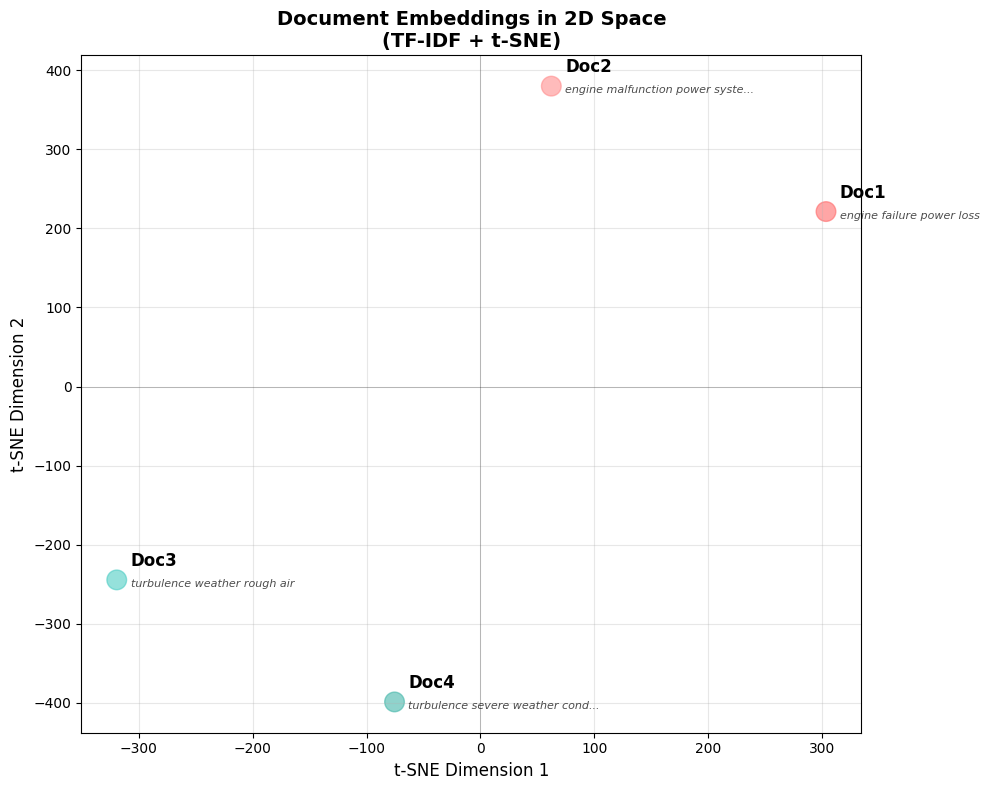


💡 Notice how:
   - Documents 1 & 2 (engine-related) are close together
   - Documents 3 & 4 (turbulence-related) are close together
   - The two clusters are separated in the coordinate space
   - t-SNE preserves local structure, making clusters more distinct


In [ ]:
print("="*70)
print("EMBEDDINGS DEMONSTRATION")
print("="*70)

# Create a simple example to visualize
example_texts = [
    "engine failure power loss",
    "engine malfunction power system",
    "turbulence weather rough air",
    "turbulence severe weather conditions",
]

print("\n📝 Example documents:")
for i, text in enumerate(example_texts, 1):
    print(f"   {i}. {text}")

# Vectorize the texts (convert to numbers)
from tactik.embeddings import vectorize_text

print("\n🔄 Converting text to TF-IDF vectors...")
tfidf_matrix, vectorizer, vocab_size = vectorize_text(example_texts)

print(f"\n✓ Vectorization complete!")
print(f"   - Vocabulary size: {vocab_size} unique words")
print(f"   - Matrix shape: {tfidf_matrix.shape} (4 documents × {vocab_size} features)")

# Show the feature names (words)
feature_names = vectorizer.get_feature_names_out()
print(f"\n   - Words in vocabulary: {', '.join(feature_names)}")

# Show the numerical representation for first document
print(f"\n📊 Numerical representation of document 1:")
print(f"   '{example_texts[0]}'")
print(f"\n   TF-IDF values:")
dense_vector = tfidf_matrix[0].toarray()[0]
for word, value in zip(feature_names, dense_vector):
    if value > 0:
        print(f"      {word}: {value:.3f}")

# Reduce dimensions for visualization using t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

print(f"\n🔄 Reducing {vocab_size} dimensions to 2D using t-SNE...")

# Convert sparse matrix to dense for t-SNE
tfidf_dense = tfidf_matrix.toarray()

# Use t-SNE to reduce to 2 dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=2, n_iter=1000)
embeddings_2d = tsne.fit_transform(tfidf_dense)

print(f"✓ Dimensionality reduction complete!")
print(f"\n📍 2D Coordinates:")
for i, (x, y) in enumerate(embeddings_2d, 1):
    print(f"   Doc{i}: ({x:.3f}, {y:.3f})")

# Create visualization
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=200, alpha=0.6, c=['#FF6B6B', '#FF8E8E', '#4ECDC4', '#45B7AA'])

# Add labels for each point
for i, (x, y) in enumerate(embeddings_2d, 1):
    plt.annotate(f'Doc{i}', (x, y), xytext=(10, 10), textcoords='offset points',
                fontsize=12, fontweight='bold')
    # Add text snippet below
    short_text = example_texts[i-1][:30] + "..." if len(example_texts[i-1]) > 30 else example_texts[i-1]
    plt.annotate(short_text, (x, y), xytext=(10, -5), textcoords='offset points',
                fontsize=8, style='italic', alpha=0.7)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Document Embeddings in 2D Space\n(TF-IDF + t-SNE)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
plt.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Notice how:")
print(f"   - Documents 1 & 2 (engine-related) are close together")
print(f"   - Documents 3 & 4 (turbulence-related) are close together")
print(f"   - The two clusters are separated in the coordinate space")
print(f"   - t-SNE preserves local structure, making clusters more distinct")

#Part 3: Untuned Clustering

CLUSTERING WITH VISUALIZATION

🔄 Running clustering algorithm...
   - Using UMAP for dimensionality reduction
   - Using HDBSCAN for cluster detection
   - Computing t-SNE for visualization
Data standardized
Applying clustering with fixed parameters...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering complete: 29 clusters found, 187 noise points

✓ Clustering complete!

📊 CLUSTERING RESULTS:
   - Total documents: 347
   - Clusters found: 29
   - Noise points: 187 (53.9%)

📈 CLUSTER SIZE DISTRIBUTION:
   - Cluster 0: 8 documents (2.3%)
   - Cluster 1: 4 documents (1.2%)
   - Cluster 2: 5 documents (1.4%)
   - Cluster 3: 8 documents (2.3%)
   - Cluster 4: 7 documents (2.0%)
   - Cluster 5: 5 documents (1.4%)
   - Cluster 6: 5 documents (1.4%)
   - Cluster 7: 7 documents (2.0%)
   - Cluster 8: 3 documents (0.9%)
   - Cluster 9: 7 documents (2.0%)
   - Cluster 10: 3 documents (0.9%)
   - Cluster 11: 5 documents (1.4%)
   - Cluster 12: 3 documents (0.9%)
   - Cluster 13: 10 documents (2.9%)
   - Cluster 14: 3 documents (0.9%)
   - Cluster 15: 3 documents (0.9%)
   - Cluster 16: 4 documents (1.2%)
   - Cluster 17: 4 documents (1.2%)
   - Cluster 18: 6 documents (1.7%)
   - Cluster 19: 13 documents (3.7%)
   - Cluster 20: 6 documents (1.7%)
   - Cluster 21: 5 documents (1.4%)
 

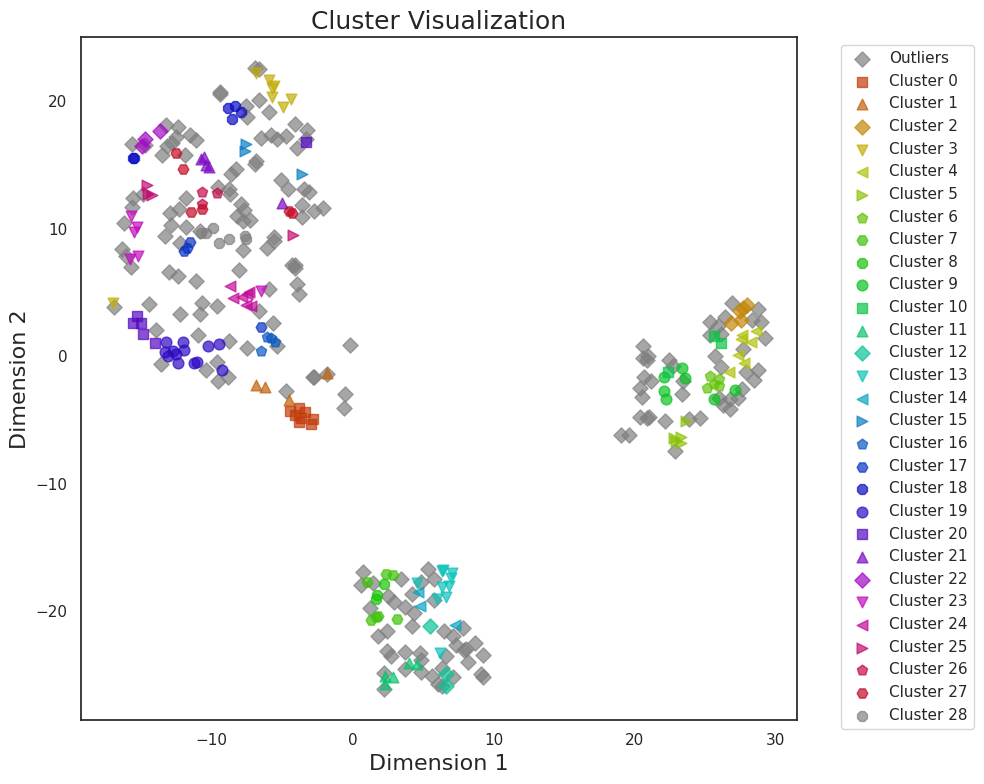

✓ Visualization displayed!

💾 To save the visualization, use:
   pipeline.visualize_clusters(save_path='clusters.png')


In [ ]:
from tactik.clustering_pipeline import ClusteringPipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("CLUSTERING WITH VISUALIZATION")
print("="*70)

# Run clustering
print("\n🔄 Running clustering algorithm...")
print("   - Using UMAP for dimensionality reduction")
print("   - Using HDBSCAN for cluster detection")
print("   - Computing t-SNE for visualization")

clustering_results = pipeline.cluster_data(
    n_neighbors=100,
    min_dist=0.0,
    metric='cosine',
    n_components=5,
    min_cluster_size=3,
    cluster_selection_method='leaf',
    compute_tsne=True,
    random_state=42
)

print("\n✓ Clustering complete!")

# Get cluster statistics
cluster_labels = clustering_results['clustering_results']['clusters']
unique_clusters = np.unique(cluster_labels[cluster_labels != -1])
n_clusters = len(unique_clusters)
n_noise = np.sum(cluster_labels == -1)

print(f"\n📊 CLUSTERING RESULTS:")
print(f"   - Total documents: {len(cluster_labels)}")
print(f"   - Clusters found: {n_clusters}")
print(f"   - Noise points: {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")

# Show cluster size distribution
print(f"\n📈 CLUSTER SIZE DISTRIBUTION:")
for cluster_id in sorted(unique_clusters):
    size = np.sum(cluster_labels == cluster_id)
    percentage = (size / len(cluster_labels)) * 100
    print(f"   - Cluster {cluster_id}: {size} documents ({percentage:.1f}%)")

# Visualize clusters using built-in visualization
print(f"\n🎨 Generating cluster visualization...")

try:
    # Use the built-in visualization method
    pipeline.visualize_clusters(
        show_outliers=True,  # Show noise points
        annotation_column=None,  # No annotations
        save_path=None  # Display instead of saving
    )

    # Show the plot
    plt.tight_layout()
    plt.show()

    print("✓ Visualization displayed!")

except Exception as e:
    print(f"⚠️  Visualization failed: {e}")

# Optional: Save visualization to file
print(f"\n💾 To save the visualization, use:")
print(f"   pipeline.visualize_clusters(save_path='clusters.png')")

## Part 3: Clustering Hyperparameter Tuning 🎯

Untuned clustering showed, we need to find the **best parameters** for our algorithms.

Think of it like tuning a radio - we need to find the right frequency to get a clear signal!

### What are we tuning?
- **UMAP parameters** - Controls how we reduce dimensions
- **HDBSCAN parameters** - Controls how we group similar documents

### Why tune?
- Different datasets need different settings
- Bad parameters → overlapping clusters or too many tiny groups
- Good parameters → clean, meaningful clusters


In [ ]:
print("\n🔄 Starting hyperparameter tuning...")
print("   This will try different parameter combinations to find the best one.")
print("   ⏱️ Estimated time: 5-15 minutes")
print()

tuning_results = pipeline.tune_and_cluster(
    min_clusters=3,
    time_limit=600,  # 10 minutes
    max_iterations=50,
    target_metric='davies_bouldin',
    standardize=True
)

print("\n✓ Tuning complete!")
print(f"   Best parameters found:")
print(f"      UMAP: {tuning_results['tuning_results']['best_params']['umap']}")
print(f"      HDBSCAN: {tuning_results['tuning_results']['best_params']['hdbscan']}")


🔄 Starting hyperparameter tuning...
   This will try different parameter combinations to find the best one.
   ⏱️ Estimated time: 5-15 minutes

Data standardized
Starting hyperparameter tuning...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Iteration 0/50: Best davies_bouldin = inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:

New best at iteration 3: davies_bouldin = 0.5526, n_clusters = 3


...

Iteration 40/50: Best davies_bouldin = 0.4931


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:

Tuning complete: Best davies_bouldin = 0.4931 in 79.69s
Applying best parameters to data...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clustering complete: 3 clusters found, 40 noise points

✓ Tuning complete!
   Best parameters found:
      UMAP: {'n_neighbors': 15, 'min_dist': 0.0, 'metric': 'cosine', 'n_components': 5}
      HDBSCAN: {'min_cluster_size': 20, 'metric': 'cityblock', 'cluster_selection_method': 'leaf'}


In [ ]:
clustering_results = pipeline.cluster_data(
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    n_components=5,
    min_cluster_size= 20,
    cluster_selection_method='leaf',
    compute_tsne=True,
    random_state=42
)

print("\n✓ Clustering complete!")

# Get cluster statistics
cluster_labels = clustering_results['clustering_results']['clusters']
unique_clusters = np.unique(cluster_labels[cluster_labels != -1])
n_clusters = len(unique_clusters)
n_noise = np.sum(cluster_labels == -1)

print(f"\n📊 CLUSTERING RESULTS:")
print(f"   - Total documents: {len(cluster_labels)}")
print(f"   - Clusters found: {n_clusters}")
print(f"   - Noise points: {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")

Data standardized
Applying clustering with fixed parameters...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering complete: 3 clusters found, 121 noise points

✓ Clustering complete!

📊 CLUSTERING RESULTS:
   - Total documents: 347
   - Clusters found: 3
   - Noise points: 121 (34.9%)



   Cluster sizes:
      Cluster 1: 86 documents (24.8%)
      Cluster 0: 73 documents (21.0%)
      Cluster 2: 67 documents (19.3%)

📈 Creating cluster visualization...


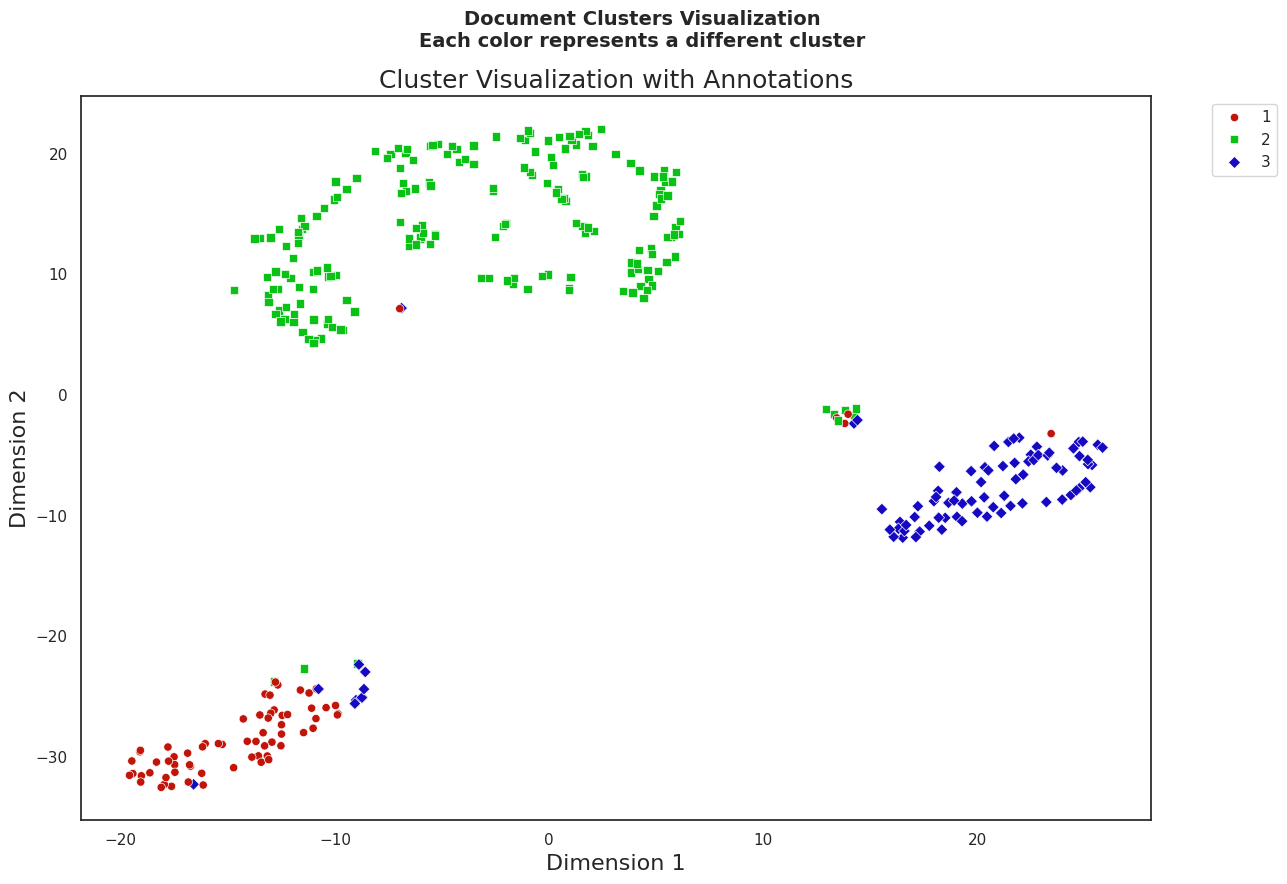


**💡 Key Takeaway:** Clustering automatically groups similar documents. Each cluster represents
   a different theme or topic in your data!


In [ ]:
print(f"\n   Cluster sizes:")
cluster_summary = pipeline.get_cluster_summary()
for idx, row in cluster_summary.head(10).iterrows():
    if idx != -1:  # Skip noise cluster
        print(f"      Cluster {idx}: {int(row['Size'])} documents ({row['Percentage']:.1f}%)")

# Visualize the clusters
print("\n📈 Creating cluster visualization...")
pipeline.visualize_clusters(annotation_column="source_file_id", show_outliers=True)
plt.suptitle('Document Clusters Visualization\nEach color represents a different cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n**💡 Key Takeaway:** Clustering automatically groups similar documents. Each cluster represents")
print("   a different theme or topic in your data!")



   Cluster sizes:
      Cluster 1: 86 documents (24.8%)
      Cluster 0: 73 documents (21.0%)
      Cluster 2: 67 documents (19.3%)

📈 Creating cluster visualization...


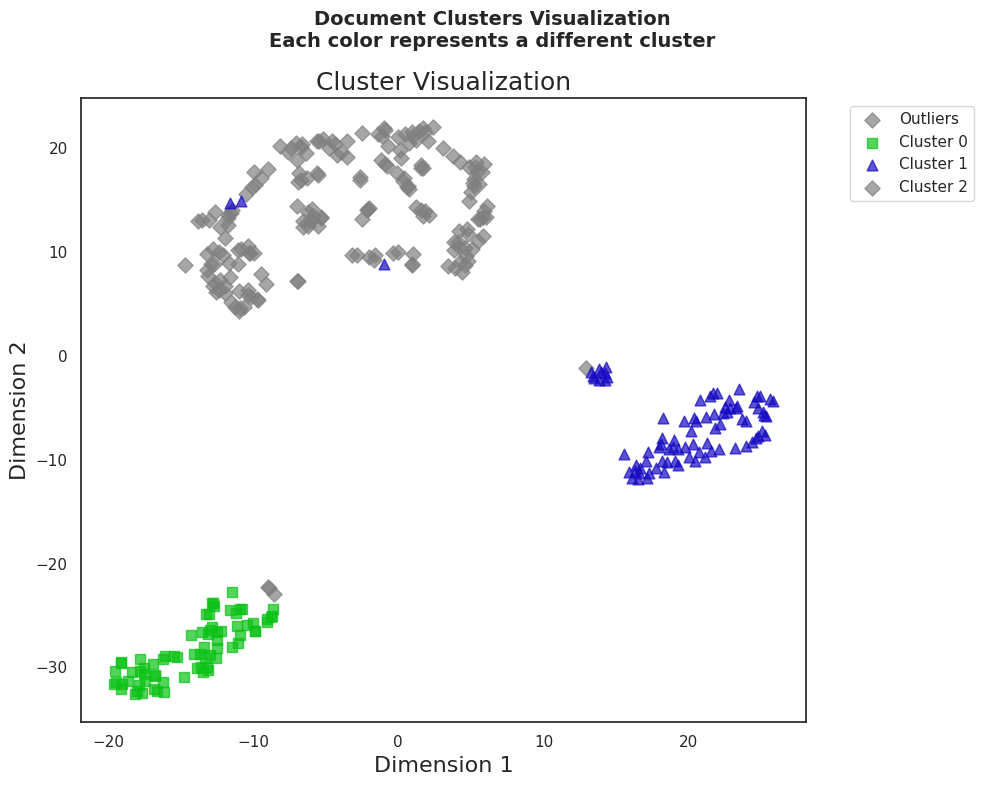


**💡 Key Takeaway:** Clustering automatically groups similar documents. Each cluster represents
   a different theme or topic in your data!


In [ ]:
print(f"\n   Cluster sizes:")
cluster_summary = pipeline.get_cluster_summary()
for idx, row in cluster_summary.head(10).iterrows():
    if idx != -1:  # Skip noise cluster
        print(f"      Cluster {idx}: {int(row['Size'])} documents ({row['Percentage']:.1f}%)")

# Visualize the clusters
print("\n📈 Creating cluster visualization...")
pipeline.visualize_clusters(annotation_column=None, show_outliers=True)
plt.suptitle('Document Clusters Visualization\nEach color represents a different cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n**💡 Key Takeaway:** Clustering automatically groups similar documents. Each cluster represents")
print("   a different theme or topic in your data!")


## Part 5: Topic Extraction 🔍

Now that we have clusters, what is each cluster **about**?

We'll use two methods:
1. **Keyword Extraction** - Find the most important words in each cluster
2. **LDA Topic Modeling** - Discover abstract topics across all documents

This helps us **interpret** and **label** our clusters!

In [ ]:
print("="*70)
print("TOPIC EXTRACTION - KEYWORDS")
print("="*70)

print("\n🔄 Extracting keywords from each cluster...")
print("   Using multiple methods:")
print("      • TF-IDF: Words important to this cluster")
print("      • YAKE: Statistically significant keywords")

keywords_df = pipeline.extract_keywords(
    tf_top_n=5,
    yake_top_n=10,
    yake_final_n=5
)

print("\n✓ Keyword extraction complete!")

# Display keywords for each cluster
print("\n📚 TOP KEYWORDS BY CLUSTER:")
print("   (These words characterize each cluster)\n")

for idx, row in keywords_df.iterrows():
    cluster_id = row['cluster']
    if cluster_id != -1:  # Skip noise cluster
        cluster_size = int(cluster_summary.loc[cluster_id, 'Size'])
        print(f"   🔵 Cluster {cluster_id} ({cluster_size} documents):")
        print(f"      TF-IDF:  {row['TF']}")
        print(f"      YAKE:    {row['Yake Short']}")
        print()

TOPIC EXTRACTION - KEYWORDS

🔄 Extracting keywords from each cluster...
   Using multiple methods:
      • TF-IDF: Words important to this cluster
      • YAKE: Statistically significant keywords

✓ Keyword extraction complete!

📚 TOP KEYWORDS BY CLUSTER:
   (These words characterize each cluster)

   🔵 Cluster 1 (86 documents):
      TF-IDF:  mask, narrative, passenger, x, passengers
      YAKE:    representative, phone, bridge, mesh, fwd

   🔵 Cluster 0 (73 documents):
      TF-IDF:  fuel, zzz, engine, tank, runway
      YAKE:    clearance, spot, pumps, ramp, student

   🔵 Cluster 2 (67 documents):
      TF-IDF:  adiz, code, potomac, vfr, clrnc
      YAKE:    plt, mission, photo, site, zjx



### LDA Topic Modeling

LDA (Latent Dirichlet Allocation) discovers **hidden topics** in your documents.
Each topic is a mixture of words, and each document is a mixture of topics.

In [ ]:
print("="*70)
print("TOPIC EXTRACTION - LDA")
print("="*70)

print("\n🔄 Training LDA topic model...")
print("   This discovers abstract topics across all documents...")

# Determine number of topics (usually 5-20)
num_topics = 6
print(f"   Using {num_topics} topics")

topic_results = pipeline.analyze_topics(
    num_topics=num_topics,
    passes=15,

)

print("\n✓ LDA topic modeling complete!")

# Display the topics
print(f"\n📚 DISCOVERED TOPICS:")
print("   (Each topic is a collection of related words)\n")

# Get topics from the model
lda_model = topic_results['model'].lda_model
for topic_id in range(min(10, num_topics)):  # Show first 10 topics
    topic_words = [word for word, _ in lda_model.show_topic(topic_id, 8)]
    print(f"   📌 Topic {topic_id}: {', '.join(topic_words)}")

# Show which topics are dominant in which clusters
print(f"\n🎯 CLUSTER-TOPIC MAPPING:")
cluster_topics = topic_results['cluster_topics']
for cluster_id in sorted(cluster_topics.keys())[:10]:  # First 10 clusters
    if cluster_id != -1:
        print(f"   Cluster {cluster_id}: Topics {cluster_topics[cluster_id]}")

print("\n**💡 Key Takeaway:** Keywords and topics help us understand what each cluster represents.")
print("   Use these to create human-readable labels for your clusters!")

TOPIC EXTRACTION - LDA

🔄 Training LDA topic model...
   This discovers abstract topics across all documents...
   Using 6 topics


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


✓ LDA topic modeling complete!

📚 DISCOVERED TOPICS:
   (Each topic is a collection of related words)

   📌 Topic 0: arpt, twr, tfr, ctlr, freq, stated, clrnc, class
   📌 Topic 1: fuel, zzz, engine, tank, runway, left, landing, checklist
   📌 Topic 2: adiz, clrnc, rwy, arpt, vfr, class, plt, b
   📌 Topic 3: ctlr, tfr, dep, xponder, code, advised, vfr, gave
   📌 Topic 4: adiz, ctlr, plt, squawk, plan, potomac, w, code
   📌 Topic 5: mask, passenger, x, passengers, fa, seat, policy, nose

🎯 CLUSTER-TOPIC MAPPING:
   Cluster 0: Topics [1, 5, 3]
   Cluster 1: Topics [5, 0, 4]
   Cluster 2: Topics [2, 4, 3]

**💡 Key Takeaway:** Keywords and topics help us understand what each cluster represents.
   Use these to create human-readable labels for your clusters!


## Part 6: Putting It All Together 🎉

Let's look at some actual documents from each cluster to see if the clustering makes sense!

In [ ]:
print("="*70)
print("CLUSTER EXAMPLES - SEEING RESULTS IN CONTEXT")
print("="*70)

print("\nLet's examine real documents from each cluster:\n")

# For each cluster, show sample documents with their keywords
for cluster_id in sorted(unique_clusters)[:5]:  # Show first 5 clusters
    # Get cluster info
    cluster_docs = pipeline.df[pipeline.df['Clusters'] == cluster_id]
    cluster_size = len(cluster_docs)

    # Get keywords for this cluster
    cluster_keywords = keywords_df[keywords_df['cluster'] == cluster_id]
    if len(cluster_keywords) > 0:
        keywords = cluster_keywords['TF'].iloc[0]
    else:
        keywords = "N/A"

    print(f"{'='*70}")
    print(f"🔵 CLUSTER {cluster_id}")
    print(f"{'='*70}")
    print(f"   Size: {cluster_size} documents")
    print(f"   Keywords: {keywords}")
    print(f"\n   📄 Sample documents:")

    # Show 3 sample documents
    for i, (idx, row) in enumerate(cluster_docs.head(3).iterrows(), 1):
        doc_text = row[text_column]
        # Truncate if too long
        if len(doc_text) > 150:
            doc_text = doc_text[:150] + "..."
        print(f"\n      {i}. {doc_text}")

    print()

print(f"\n{'='*70}")
print("✨ WORKSHOP COMPLETE! ✨")
print(f"{'='*70}")

CLUSTER EXAMPLES - SEEING RESULTS IN CONTEXT

Let's examine real documents from each cluster:

🔵 CLUSTER 0
   Size: 73 documents
   Keywords: fuel, zzz, engine, tank, runway

   📄 Sample documents:

      1. WHILE IN CRUISE AT FL370; THE CAPT LEFT THE FLT STATION TO RELIEVE HIMSELF. I WAS PERFORMING SOME FUEL XFEED ADJUSTMENTS AT THIS TIME AND THE FO WAS L...

      2. I was flying a PA super cub from ZZZ and was over ZZZ1 when I experienced loss of power in the engine. I landed the aircraft safely at ZZZ1; as I was ...

      3. Approximately an hour into flight at FL330; we received a Level 1-Tank 1 and 3; Tip Fuel Low warning. About 15 mins later; received a Level 2-Fuel Qty...

🔵 CLUSTER 1
   Size: 86 documents
   Keywords: mask, narrative, passenger, x, passengers

   📄 Sample documents:

      1. I was deadheading on Aircraft X. I identified myself to the A Flight Attendant (FA) (as I always do) as a safety and security asset.The flight was nea...

      2. Pushed away from gate.